# Prediction Suhu Udara

Nama: Yudha nuur cahyo

NIM: 220411100052

Mata Kuliah: Proyek sains Data

In [138]:
import numpy as np

## Memuat dataset

In [139]:
from google.colab import drive
drive.mount('/content/drive')
import pickle
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [140]:
data = pd.read_csv("/content/drive/My Drive/psd/dataset/prediksi_cuaca_permenit.csv")

In [141]:
data

,rowID,hpwren_timestamp,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,min_wind_direction,min_wind_speed,rain_accumulation,rain_duration,relative_humidity
0,0,9/10/2011 0:00,912.3,64.76,97.0,1.2,106.0,1.6,85.0,1.0,NaN,NaN,60.5
1,1,9/10/2011 0:01,912.3,63.86,161.0,0.8,215.0,1.5,43.0,0.2,0.0,0.0,39.9
2,2,9/10/2011 0:02,912.3,64.22,77.0,0.7,143.0,1.2,324.0,0.3,0.0,0.0,43.0
3,3,9/10/2011 0:03,912.3,64.40,89.0,1.2,112.0,1.6,12.0,0.7,0.0,0.0,49.5
4,4,9/10/2011 0:04,912.3,64.40,185.0,0.4,260.0,1.0,100.0,0.1,0.0,0.0,58.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003,2003,9/11/2011 9:23,916.8,57.92,207.0,1.8,213.0,2.2,200.0,1.5,0.0,0.0,73.8
2004,2004,9/11/2011 9:24,916.8,57.92,174.0,0.7,239.0,1.5,129.0,0.4,0.0,0.0,72.9
2005,2005,9/11/2011 9:25,916.9,58.10,177.0,1.9,196.0,2.2,140.0,1.4,0.0,0.0,73.8
2006,2006,9/11/2011 9:26,916.8,58.28,160.0,1.1,175.0,1.5,122.0,0.6,0.0,0.0,73.2


## Preprocessing: Extract Date Information

In [142]:
# Now you can access the columns by their names
data_filtered = data[['hpwren_timestamp', 'air_temp', 'air_pressure', 'avg_wind_speed', 'relative_humidity']]
data_filtered

,hpwren_timestamp,air_temp,air_pressure,avg_wind_speed,relative_humidity
0,9/10/2011 0:00,64.76,912.3,1.2,60.5
1,9/10/2011 0:01,63.86,912.3,0.8,39.9
2,9/10/2011 0:02,64.22,912.3,0.7,43.0
3,9/10/2011 0:03,64.40,912.3,1.2,49.5
4,9/10/2011 0:04,64.40,912.3,0.4,58.8
...,...,...,...,...,...
2003,9/11/2011 9:23,57.92,916.8,1.8,73.8
2004,9/11/2011 9:24,57.92,916.8,0.7,72.9
2005,9/11/2011 9:25,58.10,916.9,1.9,73.8
2006,9/11/2011 9:26,58.28,916.8,1.1,73.2


## Mengubah hpwren_timestamp menjadi format datetime.

Dengan format datetime, Anda dapat dengan mudah melakukan operasi Time Series

In [143]:
# Preprocessing
data_filtered['hpwren_timestamp'] = pd.to_datetime(data_filtered['hpwren_timestamp'])
data_filtered['Year'] = data_filtered['hpwren_timestamp'].dt.year
data_filtered['Month'] = data_filtered['hpwren_timestamp'].dt.month

<ipython-input-143-50e89e908c6f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['hpwren_timestamp'] = pd.to_datetime(data_filtered['hpwren_timestamp'])
<ipython-input-143-50e89e908c6f>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['Year'] = data_filtered['hpwren_timestamp'].dt.year
<ipython-input-143-50e89e908c6f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

In [144]:
print(data_filtered.describe())

                    hpwren_timestamp     air_temp  air_pressure  \
count                           2008  2008.000000   2008.000000   
mean   2011-09-10 16:43:29.999999744    58.316574    913.588695   
min              2011-09-10 00:00:00    51.980000    911.100000   
25%              2011-09-10 08:21:45    53.960000    912.400000   
50%              2011-09-10 16:43:30    57.560000    913.500000   
75%              2011-09-11 01:05:15    62.420000    914.700000   
max              2011-09-11 09:27:00    68.000000    916.900000   
std                              NaN     4.714257      1.418736   

       avg_wind_speed  relative_humidity    Year   Month  
count     2008.000000        2008.000000  2008.0  2008.0  
mean         1.973855          74.550149  2011.0     9.0  
min          0.100000          29.000000  2011.0     9.0  
25%          0.800000          64.400000  2011.0     9.0  
50%          1.500000          77.200000  2011.0     9.0  
75%          2.500000          89.500000  

Menampilkan statistik deskriptif seperti rata-rata, nilai minimum, maksimum, dll., untuk kolom numerik dalam DataFrame.

### Menghitung jumlah nilai kosong

In [145]:
print(data_filtered.isnull().sum())

hpwren_timestamp     0
air_temp             0
air_pressure         0
avg_wind_speed       0
relative_humidity    0
Year                 0
Month                0
dtype: int64


## Mengisi data yang kosong dengan Mean atau Median

In [146]:
# data_filtered['avg_wind_speed'].fillna(data_filtered['avg_wind_speed'].median(), inplace=True)

### Membuat grafik time series untuk menunjukkan tren impor minyak dari waktu ke waktu.

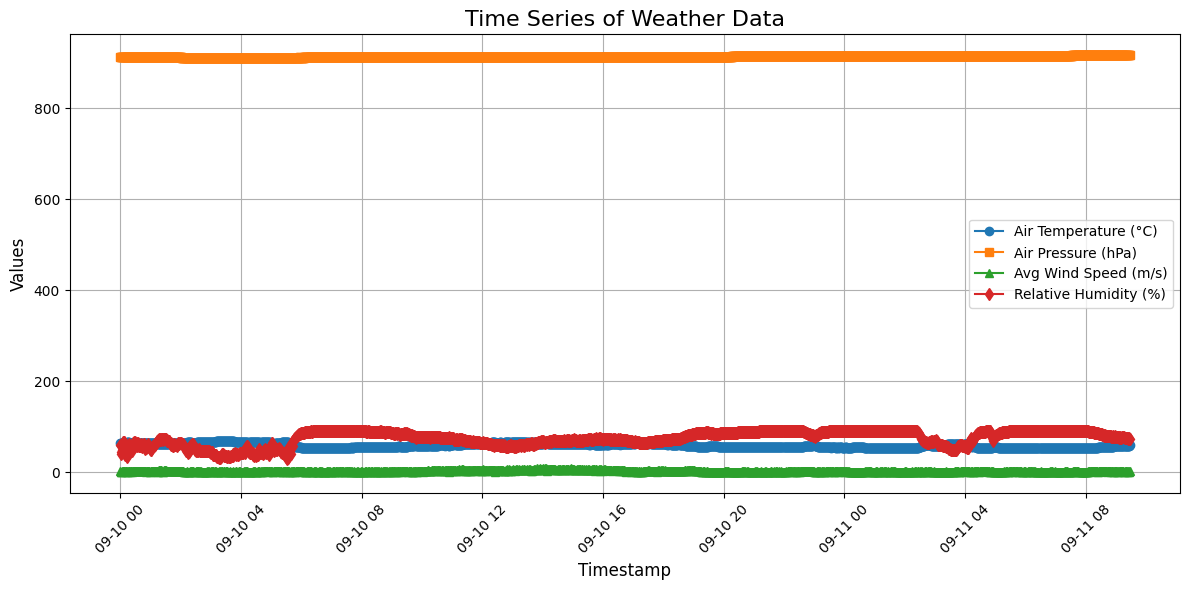

In [147]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(data_filtered)

# Konversi hpwren_timestamp ke datetime
df['hpwren_timestamp'] = pd.to_datetime(df['hpwren_timestamp'])

# Mengisi NaN di avg_wind_speed dengan interpolasi
df['avg_wind_speed'] = df['avg_wind_speed'].interpolate(method='linear')

# Plot time series untuk air_temp, air_pressure, avg_wind_speed, relative_humidity
plt.figure(figsize=(12, 6))

plt.plot(df['hpwren_timestamp'], df['air_temp'], label='Air Temperature (°C)', marker='o')
plt.plot(df['hpwren_timestamp'], df['air_pressure'], label='Air Pressure (hPa)', marker='s')
plt.plot(df['hpwren_timestamp'], df['avg_wind_speed'], label='Avg Wind Speed (m/s)', marker='^')
plt.plot(df['hpwren_timestamp'], df['relative_humidity'], label='Relative Humidity (%)', marker='d')

# Menambahkan judul, label, dan legenda
plt.title('Time Series of Weather Data', fontsize=16)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Tampilkan plot
plt.tight_layout()
plt.show()


In [148]:
prices = data['air_temp'].values
print(prices)

[64.76 63.86 64.22 ... 58.1  58.28 58.46]


### Mengambil kolom nilai impor minyak dalam bentuk array numpy untuk digunakan dalam analisis.

In [149]:
# # Mengambil kolom harga dan mengubahnya menjadi array numpy
# prices = data['Crude oil imports from the World to the US (a thousand barrels)'].values
# print(prices)

### melakukan sliding window

disini kita menguakan sliding window pada semua fitur jika hubungan antar fitur signifikan.
dan juga sliding window hanya pada target untuk pendekatan yang lebih sederhana.
Kedua pendekatan bisa diuji dan dibandingkan untuk menentukan mana yang memberikan performa prediksi terbaik.

In [150]:
def create_sliding_window(df, target, lag):
    # Buat salinan dataframe
    df_sliding = df.copy()
    features = df.columns.tolist()

    # Membuat lag untuk semua fitur
    for feature in features:
        for i in range(1, lag + 1):
            df_sliding[f'{feature}_lag_{i}'] = df[feature].shift(i)

    # Menghapus baris dengan nilai NaN akibat lagging
    df_sliding = df_sliding.dropna().reset_index(drop=True)

    return df_sliding

# Contoh penggunaan
lag = 3
df_sliding = create_sliding_window(df[['air_temp', 'air_pressure', 'relative_humidity']], target='air_temp', lag=lag)
print(df_sliding)


      air_temp  air_pressure  relative_humidity  air_temp_lag_1  \
0        64.40         912.3               49.5           64.22   
1        64.40         912.3               58.8           64.40   
2        63.50         912.3               62.6           64.40   
3        62.78         912.3               65.6           63.50   
4        62.42         912.3               65.2           62.78   
...        ...           ...                ...             ...   
2000     57.92         916.8               73.8           57.74   
2001     57.92         916.8               72.9           57.92   
2002     58.10         916.9               73.8           57.92   
2003     58.28         916.8               73.2           58.10   
2004     58.46         916.8               72.6           58.28   

      air_temp_lag_2  air_temp_lag_3  air_pressure_lag_1  air_pressure_lag_2  \
0              63.86           64.76               912.3               912.3   
1              64.22           63.8

Mendefinisikan fungsi sliding_window untuk membuat data input (X) dan target (y) menggunakan metode jendela geser.

### normalisasi data

In [152]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def create_sliding_window_with_normalization(df, target, lag):
    # Buat salinan dataframe
    df_sliding = df.copy()
    features = df.columns.tolist()

    # Membuat lag untuk semua fitur
    for feature in features:
        for i in range(1, lag + 1):
            df_sliding[f'{feature}_lag_{i}'] = df[feature].shift(i)

    # Menghapus baris dengan nilai NaN akibat lagging
    df_sliding = df_sliding.dropna().reset_index(drop=True)

    # Normalisasi semua fitur (termasuk lag)
    scaler = MinMaxScaler()
    normalized_data = scaler.fit_transform(df_sliding)
    df_normalized = pd.DataFrame(normalized_data, columns=df_sliding.columns)

    return df_normalized

df = pd.DataFrame(df_sliding)

lag = 3
normalized_df = create_sliding_window_with_normalization(df, target='air_temp', lag=lag)
normalized_df

,air_temp,air_pressure,relative_humidity,air_temp_lag_1,air_temp_lag_2,air_temp_lag_3,air_pressure_lag_1,air_pressure_lag_2,air_pressure_lag_3,relative_humidity_lag_1,...,air_pressure_lag_3_lag_3,relative_humidity_lag_1_lag_1,relative_humidity_lag_1_lag_2,relative_humidity_lag_1_lag_3,relative_humidity_lag_2_lag_1,relative_humidity_lag_2_lag_2,relative_humidity_lag_2_lag_3,relative_humidity_lag_3_lag_1,relative_humidity_lag_3_lag_2,relative_humidity_lag_3_lag_3
0,0.674157,0.206897,0.588424,0.719101,0.775281,0.775281,0.206897,0.206897,0.210526,0.540193,...,0.210526,0.479100,0.329582,0.225080,0.329582,0.225080,0.175241,0.225080,0.175241,0.506431
1,0.651685,0.206897,0.581994,0.674157,0.719101,0.775281,0.206897,0.206897,0.210526,0.588424,...,0.210526,0.540193,0.479100,0.329582,0.479100,0.329582,0.225080,0.329582,0.225080,0.175241
2,0.640449,0.206897,0.591640,0.651685,0.674157,0.719101,0.206897,0.206897,0.210526,0.581994,...,0.210526,0.588424,0.540193,0.479100,0.540193,0.479100,0.329582,0.479100,0.329582,0.225080
3,0.640449,0.206897,0.475884,0.640449,0.651685,0.674157,0.206897,0.206897,0.210526,0.591640,...,0.210526,0.581994,0.588424,0.540193,0.588424,0.540193,0.479100,0.540193,0.479100,0.329582
4,0.640449,0.206897,0.152733,0.640449,0.640449,0.651685,0.206897,0.206897,0.210526,0.475884,...,0.210526,0.591640,0.581994,0.588424,0.581994,0.588424,0.540193,0.588424,0.540193,0.479100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1997,0.370787,0.982759,0.720257,0.359551,0.359551,0.359551,0.982759,0.982759,1.000000,0.728296,...,1.000000,0.741158,0.731511,0.742765,0.731511,0.742765,0.739550,0.742765,0.739550,0.721865
1998,0.370787,0.982759,0.705788,0.370787,0.359551,0.359551,0.982759,0.982759,1.000000,0.720257,...,1.000000,0.728296,0.741158,0.731511,0.741158,0.731511,0.742765,0.731511,0.742765,0.739550
1999,0.382022,1.000000,0.720257,0.370787,0.370787,0.359551,0.982759,0.982759,1.000000,0.705788,...,1.000000,0.720257,0.728296,0.741158,0.728296,0.741158,0.731511,0.741158,0.731511,0.742765
2000,0.393258,0.982759,0.710611,0.382022,0.370787,0.370787,1.000000,0.982759,1.000000,0.720257,...,1.000000,0.705788,0.720257,0.728296,0.720257,0.728296,0.741158,0.728296,0.741158,0.731511


- Menggunakan MinMaxScaler untuk normalisasi data agar berada dalam rentang 0-1.
- Normalisasi dilakukan pada data input (X) dan target (y).

### Membagi data menjadi set latih dan uji

In [154]:
def split_data_for_prediction(df, target_column, test_size=0.2):
    # Pisahkan fitur dan target
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Membagi data menjadi data latih dan data uji
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    return X_train, X_test, y_train, y_test

# Membagi data latih dan data uji
target_column = 'air_temp'
X_train, X_test, y_train, y_test = split_data_for_prediction(normalized_df, target_column=target_column, test_size=0.2)

print("X_train:")
print(X_train.shape)
print("y_train:")
print(y_train.shape)
print("X_test:")
print(X_test.shape)
print("y_test:")
print(y_test.shape)

X_train:
(1601, 38)
y_train:
(1601,)
X_test:
(401, 38)
y_test:
(401,)


- Membagi data menjadi set latih dan uji (80%-20%).
- Melatih model BaggingRegressor dengan LinearRegression sebagai estimasi dasar.
- Mengukur kinerja model menggunakan Mean Squared Error (MSE).

### Melatih model BaggingRegressor

In [163]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import pickle

In [157]:
# mmenggunakan linearRegression
from sklearn.linear_model import LinearRegression

linear= LinearRegression()
bagging_model = BaggingRegressor(estimator=linear, n_estimators=10, random_state=42)

# Melatih model pada data
bagging_model.fit(X_train, y_train)

BaggingRegressor(estimator=LinearRegression(), random_state=42)

In [158]:
def evaluate_model(model, X_test, y_test):
    # Melakukan prediksi pada data uji
    y_pred = model.predict(X_test)

    # Menghindari pembagian dengan nol pada perhitungan MAPE
    non_zero_indices = y_test != 0
    y_test_non_zero = y_test[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]

    # Menghitung MAE, RMSE, dan MAPE
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test_non_zero - y_pred_non_zero) / y_test_non_zero)) * 100

    return mae, rmse, mape

In [159]:
# Evaluasi model
mae, rmse, mape = evaluate_model(bagging_model, X_test, y_test)

print("Model Bagging Regressor telah dilatih.")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}%")

Model Bagging Regressor telah dilatih.
MAE: 0.0077198240760935006
RMSE: 0.010804921657462531
MAPE: 4.435064763726207%


In [166]:
def predict_future(bagging_model, X_input, steps=15, feature_columns=None):
    """
    Melakukan prediksi dengan memastikan input X_input memiliki jumlah fitur yang sama dengan yang digunakan saat training.

    Args:
        bagging_model: Model BaggingRegressor yang sudah dilatih.
        X_input: Input awal untuk prediksi.
        steps: Berapa langkah ke depan yang ingin diprediksi.
        feature_columns: Nama fitur yang digunakan saat pelatihan.

    Returns:
        predictions: List berisi hasil prediksi selama 'steps'.
    """
    predictions = []
    current_input = X_input.reshape(1, -1)  # Ubah input menjadi array 2D yang kompatibel untuk prediksi.

    # Konversi menjadi DataFrame dengan nama fitur yang sama
    if feature_columns is not None:
        current_input = pd.DataFrame(current_input, columns=feature_columns)

    for _ in range(steps):
        # Prediksi nilai untuk langkah ke-i
        prediction = bagging_model.predict(current_input)[0]
        predictions.append(prediction)

        # Geser nilai input dan masukkan prediksi di akhir
        new_input = current_input.copy()
        new_input.iloc[0, -1] = prediction  # Perbarui nilai terakhir dengan hasil prediksi
        current_input = new_input

    return predictions


In [161]:
# Menyimpan model ke file pickle
with open('bagging_model.pkl', 'wb') as model_file:
    pickle.dump(bagging_model, model_file)

print("Model telah disimpan dalam bentuk file pkl.")

Model telah disimpan dalam bentuk file pkl.


In [167]:
# Pisahkan fitur dan target pada data latih dan uji
X_train, X_test, y_train, y_test = split_data_for_prediction(normalized_df, target_column=target_column, test_size=0.2)

# Latih model menggunakan jumlah fitur dari X_train
bagging_model.fit(X_train, y_train)

# Melakukan prediksi hanya dengan fitur yang sama seperti saat model dilatih
feature_columns = X_train.columns  # Ambil nama fitur dari X_train
X_last = X_test.iloc[-1].values  # Ambil fitur dari data uji terakhir

# Lakukan prediksi dengan hanya menggunakan fitur yang sama
predictions = predict_future(bagging_model, X_last, steps=15, feature_columns=feature_columns)

print("Prediksi untuk 15 langkah ke depan:")
print(predictions)


Prediksi untuk 15 langkah ke depan:
[0.07159164476775579, 0.041969497297402465, 0.04099220693071094, 0.040959964283151906, 0.04095890053755792, 0.04095886544258979, 0.04095886428474077, 0.040958864246541146, 0.04095886424528088, 0.0409588642452393, 0.04095886424523793, 0.04095886424523788, 0.04095886424523788, 0.04095886424523788, 0.04095886424523788]
